# Query & Plot Cluster Hertzsprung-Russel Diagram

- Step 1: Installs the required libraries for astronomy data analysis, querying, and plotting.
- Step 2: Imports the necessary modules from the installed libraries.
- Step 3: Queries the Gaia archive for data within a specified radius around a given cluster.
- Step 4: Calculates absolute magnitudes and colors from the Gaia data.
- Step 5: Generates an HR diagram, plotting absolute magnitude against color.

## Step 1: Install necessary libraries as necessary

In [2]:
# pip install astropy astroquery matplotlib

## Step 2: Import libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

## Step 3: Query Gaia data

In [24]:
# Define cluster coordinates and radius for Cone search
cluster_name = "M67"  # Example cluster
ra = 132.825 * u.deg
dec = 11.8 * u.deg
radius = 1 * u.deg

# Query Gaia
query = f"""
    SELECT source_id, ra, dec, parallax, phot_g_mean_mag, bp_rp
    FROM gaiaedr3.gaia_source 
    WHERE 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra.value}, {dec.value}, {radius.value})
    )
""" 
job = Gaia.launch_job_async(query)
gaia_data = job.get_results()
#print(gaia_data)

INFO: Query finished. [astroquery.utils.tap.core]
    source_id              ra         ... phot_g_mean_mag   bp_rp   
                          deg         ...       mag          mag    
------------------ ------------------ ... --------------- ----------
604625910880696960  133.4096666480859 ...        21.82215  2.9158669
604626082680673920 133.44596347435584 ...       21.120874  1.3921833
604626117039126784  133.3992297425306 ...       19.757692  1.8160763
604626121334201984 133.39123481371493 ...      15.1389675 0.92504597
604626151398869248 133.40903266886656 ...       18.443552   1.123579
604626151400065024  133.4091799043752 ...       20.877066  1.3843727
604626220118347264 133.39888210091777 ...       18.210526  1.5570602
604626224413347968 133.39353609655086 ...       19.284882  2.1848602
604626258773154688 133.41823715261344 ...       19.818914  2.3760357
               ...                ... ...             ...        ...
601999972170959232 131.91016695814486 ...       14.21

## Step 4: Cleanup Gaia Query Results data

In [46]:
# Create a DataFrame:
allstars = gaia_data.to_pandas()
print(allstars)
# filter allstars (temp1)
temp1 = allstars.dropna()  # Drop NaN - "not a number"
print(temp1)
# filter parallax > 0 (allstars_filtered) by creating a mask
mask = (allstars.parallax > 1)
allstars_filtered = allstars[mask]
#print(allstars_filtered)
allstars = allstars_filtered.dropna()
#print(allstars)

                source_id          ra        dec  parallax  phot_g_mean_mag  \
0      604625910880696960  133.409667  10.983092       NaN        21.822149   
1      604626082680673920  133.445963  11.008143       NaN        21.120874   
2      604626117039126784  133.399230  10.980871 -0.501336        19.757692   
3      604626121334201984  133.391235  10.987632  0.906051        15.138968   
4      604626151398869248  133.409033  11.001376  0.298192        18.443552   
...                   ...         ...        ...       ...              ...   
20300  602000139674349440  131.915386  12.231429 -0.997808        19.997879   
20301  602000174033669888  131.919848  12.244765  2.275915        14.773335   
20302  602000174034249856  131.913596  12.243519 -2.367392        20.741451   
20303  602000178329388288  131.915939  12.245764  1.466565        15.670284   
20304  602003128971602048  131.920327  12.256240 -0.842204        20.396507   

          bp_rp  
0      2.915867  
1      1.392183

## Step 4: Calculate absolute magnitude and add to DataFrame

### Review Formulas (we drived these in the Star MAgnitudes Module!)
#### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
#### Note that this quantity appears in the equations below to calculate magnitudes and distance
### 1. How to calculate Magnitudes when distance (in pc) is known
#### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
### 2. How to calculate Magnitudes when parallax (in arc-sec) is known
#### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
### 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
##### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
#### 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
##### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

In [48]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

distance_modulus = -5 * np.log10(allstars['parallax']) + 10
abs_mag = allstars['phot_g_mean_mag'] - distance_modulus
# add abs_mag back to dataframe
allstars['abs_mag'] = abs_mag
#print(allstars)

                source_id          ra        dec  parallax  phot_g_mean_mag  \
7      604626224413347968  133.393536  11.004873  1.041490        19.284882   
10     604626293132819072  133.431111  11.015676  1.177280        17.560364   
11     604626323197563008  133.403503  11.009986  1.073133        18.626163   
14     604626460636516864  133.447751  11.010241  1.824420        18.525936   
16     604626460637801728  133.448363  11.018673  3.406057        20.652187   
...                   ...         ...        ...       ...              ...   
20280  601999315040944768  131.892912  12.174780  1.474835        20.260359   
20288  601999766013494272  131.921922  12.199955  1.731783        19.529863   
20295  601999972170959232  131.910167  12.219803  1.440411        14.216102   
20301  602000174033669888  131.919848  12.244765  2.275915        14.773335   
20303  602000178329388288  131.915939  12.245764  1.466565        15.670284   

          bp_rp    abs_mag  
7      2.184860   9.37

/tmp/ipykernel_43897/673090460.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  allstars['abs_mag'] = abs_mag


## Step 5: Plot HR diagram

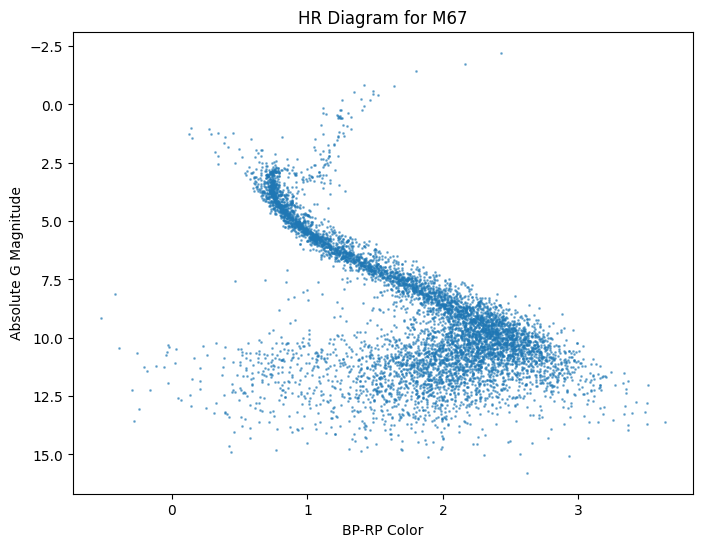

In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(allstars['bp_rp'], allstars['abs_mag'], s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for {cluster_name}")
plt.show()

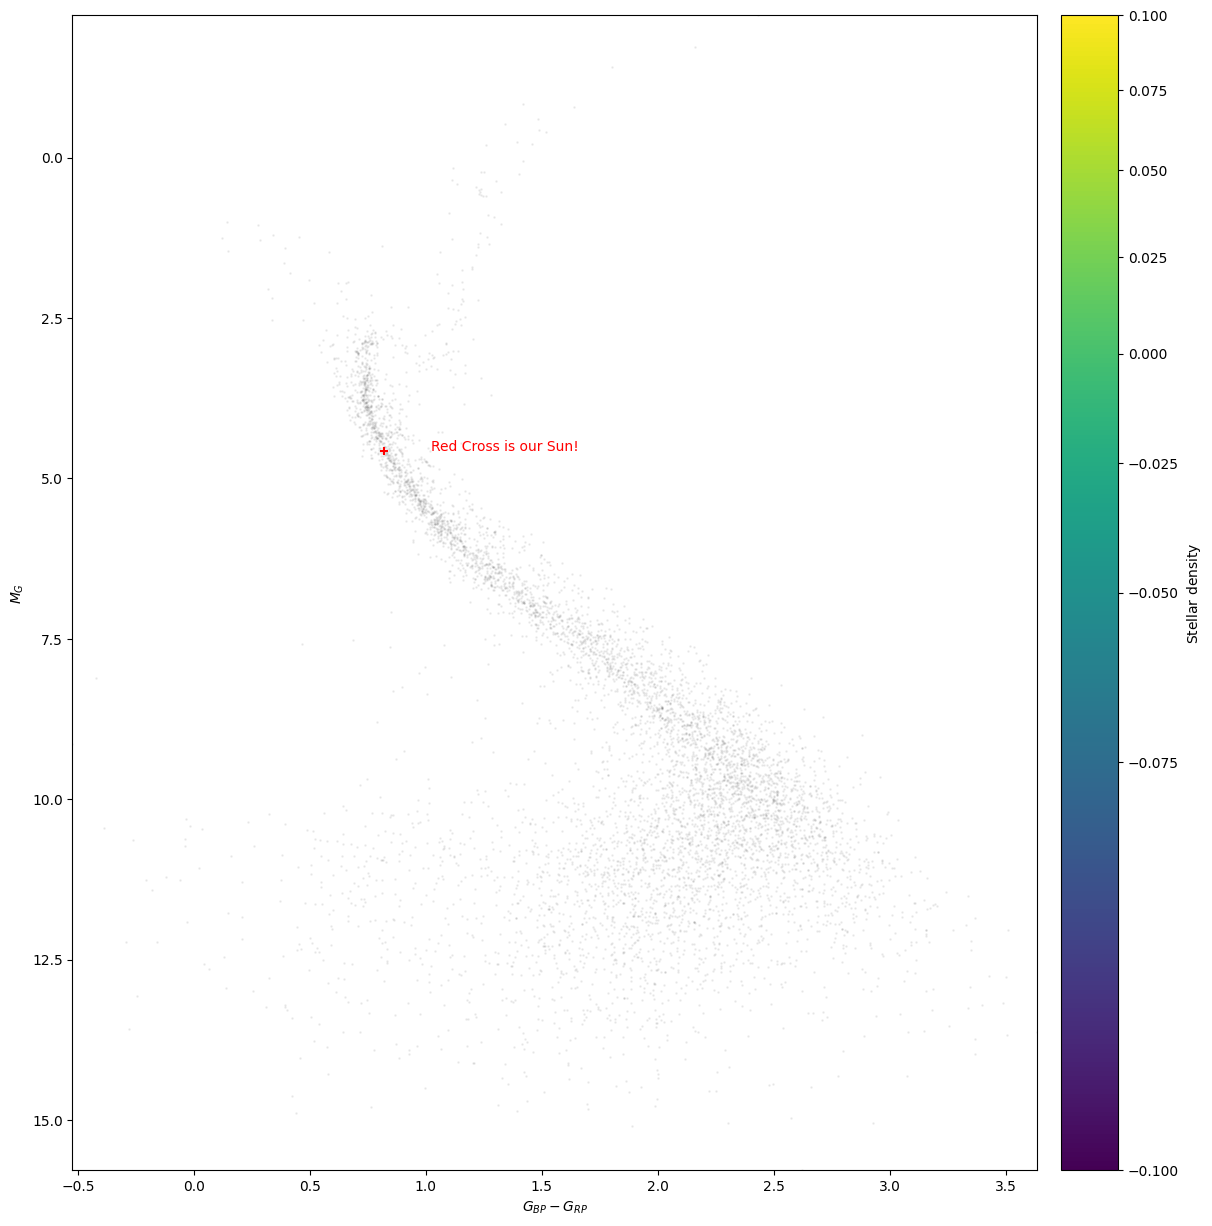

In [52]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))

# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * math.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

# only show 2D-histogram for bins with more than 10 stars in them
ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
#h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
h = ax.hist2d(allstars['bp_rp'], allstars['abs_mag'], bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(allstars['bp_rp'], allstars['abs_mag'], alpha=0.05, s=1, color='k', zorder=0)

plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"m67.png", dpi=140)
plt.show()